In [ ]:
pip install catboost xgboost scikit-learn==1.5.0 gensim

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
import gensim
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
kaggle_df = pd.read_csv('/content/kaggle_df.csv')

kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     1000 non-null   object 
 1   Display_Name                 1000 non-null   object 
 2   Gender                       1000 non-null   object 
 3   notebook_url                 1000 non-null   object 
 4   code_location                1000 non-null   object 
 5   labels                       1000 non-null   object 
 6   top_labels                   1000 non-null   object 
 7   code_sections                1000 non-null   object 
 8   markdown_sections            1000 non-null   object 
 9   all_sections                 1000 non-null   object 
 10  only_code_in_code_sections   1000 non-null   object 
 11  number_of_lines              1000 non-null   float64
 12  names_set                    1000 non-null   object 
 13  num_of_sections    

In [ ]:
kaggle_df.head()

,Username,Display_Name,Gender,notebook_url,code_location,labels,top_labels,code_sections,markdown_sections,all_sections,...,function_density,loop_density,condition_density,comment_tokens_density,avg_var_name_length,comment_to_code_ratio,avg_func_length,code_to_markdown_ratio,avg_markdown_lines_length,markdown_sentiment
0,faridrizqis,Farid Rizqi S,male,https://www.kaggle.com/code/faridrizqis/sql-sy...,D:/learning/thesis/male/faridrizqis/sql-syntax...,['Heart Failure Prediction Dataset'],{'Heart Failure Prediction Dataset'},['# Install pandasql\n!pip install -q pandasql...,['# About Pandasql\npandasql allows you to que...,['# About Pandasql\npandasql allows you to que...,...,0.000000,0.000000,0.000000,0.537830,5.588235,0.226109,0.000000,7.078920,5.000000,-0.109450
1,felipefonte99,Felipe Loque,male,https://www.kaggle.com/code/felipefonte99/cnn-...,D:/learning/thesis/male/felipefonte99/cnn-on-i...,['LANL Earthquake Prediction'],{'LANL Earthquake Prediction'},['import os\nimport cv2\nimport numpy as np\ni...,['### This kernel was created to the <a target...,['### This kernel was created to the <a target...,...,0.004651,0.027907,0.013953,0.090038,8.858407,0.083580,21.000000,11.510467,1.500000,0.130800
2,para24,JP,male,https://www.kaggle.com/code/para24/ovr-vs-mult...,D:/learning/thesis/male/para24/ovr-vs-multiout...,['Mechanisms of Action (MoA) Prediction'],{'Mechanisms of Action (MoA) Prediction'},"['import os, sys\n\nimport numpy as np\nfrom s...",['* [1. Import Data](#import-data)\n* [2. Data...,['* [1. Import Data](#import-data)\n* [2. Data...,...,0.014706,0.039216,0.009804,0.058537,9.352381,0.255862,7.666667,3.847273,2.363636,0.043073
3,ldm314,Brian,male,https://www.kaggle.com/code/ldm314/dnn-keras-s...,D:/learning/thesis/male/ldm314/dnn-keras-santa...,['Santander Customer Transaction Prediction'],{'Santander Customer Transaction Prediction'},['import os\nimport gc\nimport pickle\nfrom pa...,[],['import os\nimport gc\nimport pickle\nfrom pa...,...,0.038202,0.013483,0.033708,0.232595,6.838235,0.000153,11.142857,6793.500000,0.000000,0.000000
4,tracyporter,Tracy Porter,female,https://www.kaggle.com/code/tracyporter/play-3...,D:/learning/thesis/female/tracyporter/play-3-1...,['Explore Multi-Label Classification with an E...,{'Explore Multi-Label Classification with an E...,['import numpy as np # linear algebra\nimport ...,['Problem statement\n\nThis is a miltilabel cl...,['Problem statement\n\nThis is a miltilabel cl...,...,0.000000,0.031414,0.010471,0.142857,6.018519,0.123255,0.000000,8.551282,1.111111,-0.051828


In [ ]:
def concatenate_code_sections(row, unique_char):
    code_list = eval(row)
    concatenated_code = unique_char.join(code_list)
    return concatenated_code

unique_char = '\n'  # Using Unit Separator (ASCII 31) as a unique character

kaggle_df['parsed_code'] = kaggle_df['code_sections'].apply(concatenate_code_sections, unique_char=unique_char)

In [ ]:
import torch
from transformers import RobertaTokenizer, RobertaModel
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight
import math

model_name = "neulab/codebert-python"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

code_snippets = kaggle_df['parsed_code'].tolist()

# Step 1: Encode the code snippets using CodeBERT
def get_embeddings(code_snippet):
    inputs = tokenizer(code_snippet, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the last hidden state of the [CLS] token as the embedding
    return outputs.last_hidden_state[:, 0, :].numpy()

# Get embeddings for all code snippets
embeddings = np.vstack([get_embeddings(snippet) for snippet in code_snippets])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/703 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at neulab/codebert-python and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
min_samples = 10 ** (math.floor(math.log10(len(code_snippets))) - 1)

min_samples

100

In [ ]:
# Step 2: Apply DBSCAN for clustering and outlier detection
dbscan = DBSCAN(eps=0.025, min_samples=min_samples, metric='cosine', n_jobs=-1)
db_labels = dbscan.fit_predict(embeddings)

# Step 3: Identify and handle outliers
outliers = np.where(db_labels == -1)[0]

# Output some statistics
print(f'Removed {len(outliers)} outliers.')
print(f'Retained {len(db_labels) - len(outliers)} code snippets.')

Removed 189 outliers.
Retained 811 code snippets.


In [ ]:
# Remove outliers from the DataFrame
kaggle_df.reset_index(drop=True, inplace=True)
kaggle_df = kaggle_df[~kaggle_df.index.isin(outliers)]

kaggle_df.Gender.value_counts()

,count
Gender,
male,442
female,369


In [ ]:
X=kaggle_df.drop('Gender',axis=1)
Y=kaggle_df.Gender.map({"male": 1, "female": 0})

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 811 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     811 non-null    object 
 1   Display_Name                 811 non-null    object 
 2   notebook_url                 811 non-null    object 
 3   code_location                811 non-null    object 
 4   labels                       811 non-null    object 
 5   top_labels                   811 non-null    object 
 6   code_sections                811 non-null    object 
 7   markdown_sections            811 non-null    object 
 8   all_sections                 811 non-null    object 
 9   only_code_in_code_sections   811 non-null    object 
 10  number_of_lines              811 non-null    float64
 11  names_set                    811 non-null    object 
 12  num_of_sections              811 non-null    int64  
 13  token_count              

# Non text features

In [ ]:
X_nontext=X.select_dtypes(exclude=['object'])
X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
Index: 811 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   number_of_lines              811 non-null    float64
 1   num_of_sections              811 non-null    int64  
 2   token_count                  811 non-null    int64  
 3   variables_count              811 non-null    int64  
 4   function_count               811 non-null    int64  
 5   loop_count                   811 non-null    int64  
 6   condition_count              811 non-null    int64  
 7   single_line_comment_density  811 non-null    float64
 8   function_density             811 non-null    float64
 9   loop_density                 811 non-null    float64
 10  condition_density            811 non-null    float64
 11  comment_tokens_density       811 non-null    float64
 12  avg_var_name_length          811 non-null    float64
 13  comment_to_code_ratio    

In [ ]:
X_train_nontext, X_test_nontext, y_train, y_test = train_test_split(X_nontext, Y, test_size=0.2, random_state=0,stratify=Y)

# KNN

In [ ]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',KNeighborsClassifier())])

In [ ]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6095527728085867


In [ ]:
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 7, 'classifier__weights': 'distance'}
Best F1 score found:  0.623748518053679
Test set F1 score:  0.6781609195402298


# Random Forest

In [ ]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',RandomForestClassifier())])

In [ ]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6542754919499105


In [ ]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found:  {'classifier__bootstrap': False, 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best F1 score found:  0.67971205712589
Test set F1 score:  0.7368421052631579


# Cat Boost

In [ ]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',CatBoostClassifier(iterations=10))])

In [ ]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

Learning rate set to 0.5
0:	learn: 0.6615433	total: 46.9ms	remaining: 422ms
1:	learn: 0.6423670	total: 48.3ms	remaining: 193ms
2:	learn: 0.6129886	total: 49.3ms	remaining: 115ms
3:	learn: 0.5946561	total: 50.3ms	remaining: 75.5ms
4:	learn: 0.5698429	total: 51.5ms	remaining: 51.5ms
5:	learn: 0.5609546	total: 52.5ms	remaining: 35ms
6:	learn: 0.5486971	total: 53.6ms	remaining: 23ms
7:	learn: 0.5338180	total: 54.7ms	remaining: 13.7ms
8:	learn: 0.5217392	total: 55.8ms	remaining: 6.2ms
9:	learn: 0.5081689	total: 56.9ms	remaining: 0us
Learning rate set to 0.5
0:	learn: 0.6575110	total: 1.29ms	remaining: 11.6ms
1:	learn: 0.6300818	total: 2.63ms	remaining: 10.5ms
2:	learn: 0.6040133	total: 3.77ms	remaining: 8.79ms
3:	learn: 0.5875764	total: 4.86ms	remaining: 7.28ms
4:	learn: 0.5700670	total: 6.23ms	remaining: 6.23ms
5:	learn: 0.5611590	total: 7.44ms	remaining: 4.96ms
6:	learn: 0.5407972	total: 8.53ms	remaining: 3.66ms
7:	learn: 0.5335326	total: 9.85ms	remaining: 2.46ms
8:	learn: 0.5220623	total

In [ ]:
param_grid = {
    'classifier__learning_rate': [0.01, 0.1, 0.3],
    'classifier__l2_leaf_reg': [1, 5 ,10],
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_cb = grid_search.best_estimator_
y_pred = best_cb.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
0:	learn: 0.6806427	total: 1.03ms	remaining: 9.25ms
1:	learn: 0.6687982	total: 2.63ms	remaining: 10.5ms
2:	learn: 0.6569502	total: 3.76ms	remaining: 8.77ms
3:	learn: 0.6491730	total: 4.89ms	remaining: 7.33ms
4:	learn: 0.6398014	total: 5.98ms	remaining: 5.98ms
5:	learn: 0.6320989	total: 7.12ms	remaining: 4.75ms
6:	learn: 0.6236625	total: 8.28ms	remaining: 3.55ms
7:	learn: 0.6158922	total: 9.39ms	remaining: 2.35ms
8:	learn: 0.6064483	total: 10.5ms	remaining: 1.17ms
9:	learn: 0.6005270	total: 11.7ms	remaining: 0us
Best parameters found:  {'classifier__l2_leaf_reg': 10, 'classifier__learning_rate': 0.3}
Best F1 score found:  0.6483454909222965
Test set F1 score:  0.7379679144385026


# Cat with Text

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(X.parsed_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
def read_corpus(text, tokens_only=False):
    for i, line in enumerate(text):
        tokens = gensim.utils.simple_preprocess(line)
        if tokens_only:
            yield tokens
        else:
        # For training data, add tags
            yield gensim.models.doc2vec.TaggedDocument(tokens, [i])

train_corpus = list(read_corpus(X_train_text))
test_corpus = list(read_corpus(X_test_text, tokens_only=True))

In [ ]:
model = gensim.models.doc2vec.Doc2Vec(vector_size=300, min_count=2)
model.build_vocab(train_corpus)
model.train(train_corpus, total_examples=model.corpus_count, epochs=55)

In [ ]:
vectors = [model.infer_vector(train_corpus[doc_id].words) for doc_id in range(len(train_corpus))]
X_train_doc2vec = np.vstack(vectors)

test_vectors = [model.infer_vector(test_corpus[doc_id]) for doc_id in range(len(test_corpus))]
X_test_doc2vec = np.vstack(test_vectors)

X_train_doc2vec.shape , X_test_doc2vec.shape

((648, 300), (163, 300))

In [ ]:
X_train_combined=pd.concat([pd.DataFrame(X_train_doc2vec, columns=['doc2vec_'+str(i) for i in range(300)], index=X_train_nontext.index),X_train_nontext],axis=1)

X_test_combined=pd.concat([pd.DataFrame(X_test_doc2vec, columns=['doc2vec_'+str(i) for i in range(300)], index=X_test_nontext.index),X_test_nontext],axis=1)

In [ ]:
param_grid = {
    'classifier__learning_rate': [0.01, 0.1, 0.3],
    'classifier__l2_leaf_reg': [1, 5 ,10],
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_combined, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_cb = grid_search.best_estimator_
y_pred = best_cb.predict(X_test_combined)
print("Test set F1 score: ", f1_score(y_test, y_pred))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
0:	learn: 0.6918642	total: 18.2ms	remaining: 164ms
1:	learn: 0.6899498	total: 32.4ms	remaining: 130ms
2:	learn: 0.6879306	total: 45.9ms	remaining: 107ms
3:	learn: 0.6858179	total: 59.5ms	remaining: 89.2ms
4:	learn: 0.6837506	total: 73.3ms	remaining: 73.3ms
5:	learn: 0.6818000	total: 86.9ms	remaining: 57.9ms
6:	learn: 0.6799714	total: 101ms	remaining: 43.2ms
7:	learn: 0.6782052	total: 114ms	remaining: 28.6ms
8:	learn: 0.6761007	total: 128ms	remaining: 14.2ms
9:	learn: 0.6743175	total: 142ms	remaining: 0us
Best parameters found:  {'classifier__l2_leaf_reg': 10, 'classifier__learning_rate': 0.01}
Best F1 score found:  0.6472593901705346
Test set F1 score:  0.693069306930693


# Support Vector Classifier

In [ ]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',SVC(probability=True))])

In [ ]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6574955277280858


In [ ]:
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto'],
    'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found:  {'classifier__C': 100, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly'}
Best F1 score found:  0.6606561928855383
Test set F1 score:  0.6815642458100558


# SVC with Text

In [ ]:
param_grid = {
    'classifier__C': [0.01 ,0.1, 1],
    'classifier__gamma': ['scale'],
    'classifier__kernel': ['rbf', 'sigmoid']
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_combined, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test_combined)
print("Test set F1 score: ", f1_score(y_test, y_pred))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found:  {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best F1 score found:  0.712704325242079
Test set F1 score:  0.7592592592592593


              precision    recall  f1-score   support

           0       0.81      0.39      0.53        74
           1       0.65      0.92      0.76        89

    accuracy                           0.68       163
   macro avg       0.73      0.66      0.64       163
weighted avg       0.72      0.68      0.65       163

f1_score_macro :  0.6432659932659932
f1_score_weighted :  0.6539402201978889


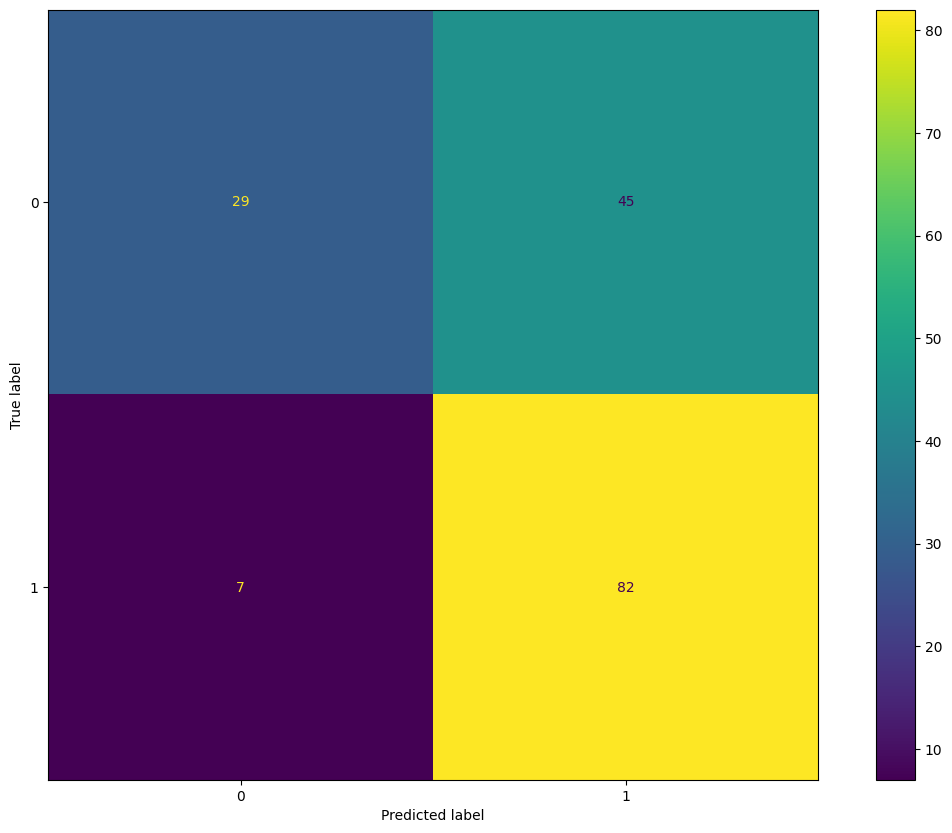

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print(classification_report(y_test, y_pred))

print("f1_score_macro : ",f1_score(y_test, y_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_test, y_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

# XGBoost

In [ ]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',XGBClassifier())])

In [ ]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6389028026237328


In [ ]:
param_grid = {
    'n_estimators': [25, 50, 100],
    'max_depth': [5, 7, 9],
    'learning_rate': [1e-3, 1e-2, 1e-1],
    'subsample': [0.4, 0.6, 0.8],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_model = XGBClassifier(eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters found:  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 100, 'subsample': 0.8}
Best F1 score found:  0.6642397012903697
Test set F1 score:  0.7539267015706806


              precision    recall  f1-score   support

           0       0.72      0.59      0.65        74
           1       0.71      0.81      0.75        89

    accuracy                           0.71       163
   macro avg       0.71      0.70      0.70       163
weighted avg       0.71      0.71      0.71       163

f1_score_macro :  0.7028892767112662
f1_score_weighted :  0.7075859722504761


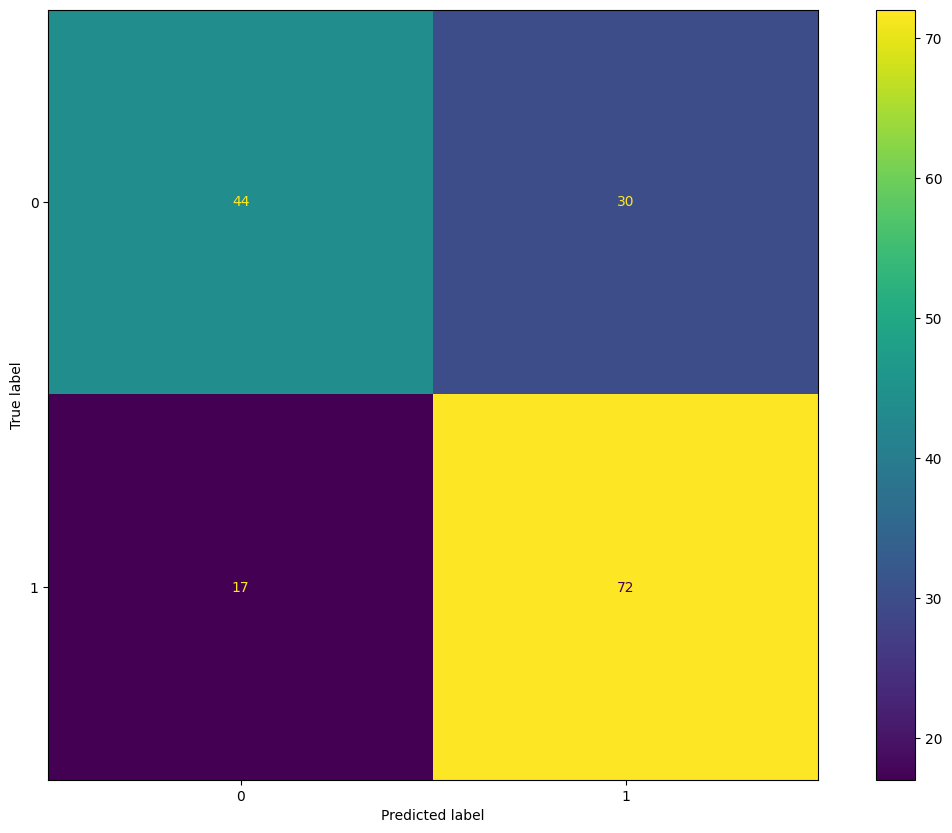

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print(classification_report(y_test, y_pred))

print("f1_score_macro : ",f1_score(y_test, y_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_test, y_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

# XGBoost With Text

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 7, 9],
    'learning_rate': [1e-3, 1e-2, 1e-1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_model = XGBClassifier(eval_metric='logloss', random_state=0)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_combined, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test_combined)
print("Test set F1 score: ", f1_score(y_test, y_pred))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found:  {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 200, 'subsample': 0.8}
Best F1 score found:  0.7119546243347321
Test set F1 score:  0.7745098039215687


              precision    recall  f1-score   support

           0       0.79      0.51      0.62        74
           1       0.69      0.89      0.77        89

    accuracy                           0.72       163
   macro avg       0.74      0.70      0.70       163
weighted avg       0.73      0.72      0.71       163

f1_score_macro :  0.69873031179685
f1_score_weighted :  0.7057038846917627


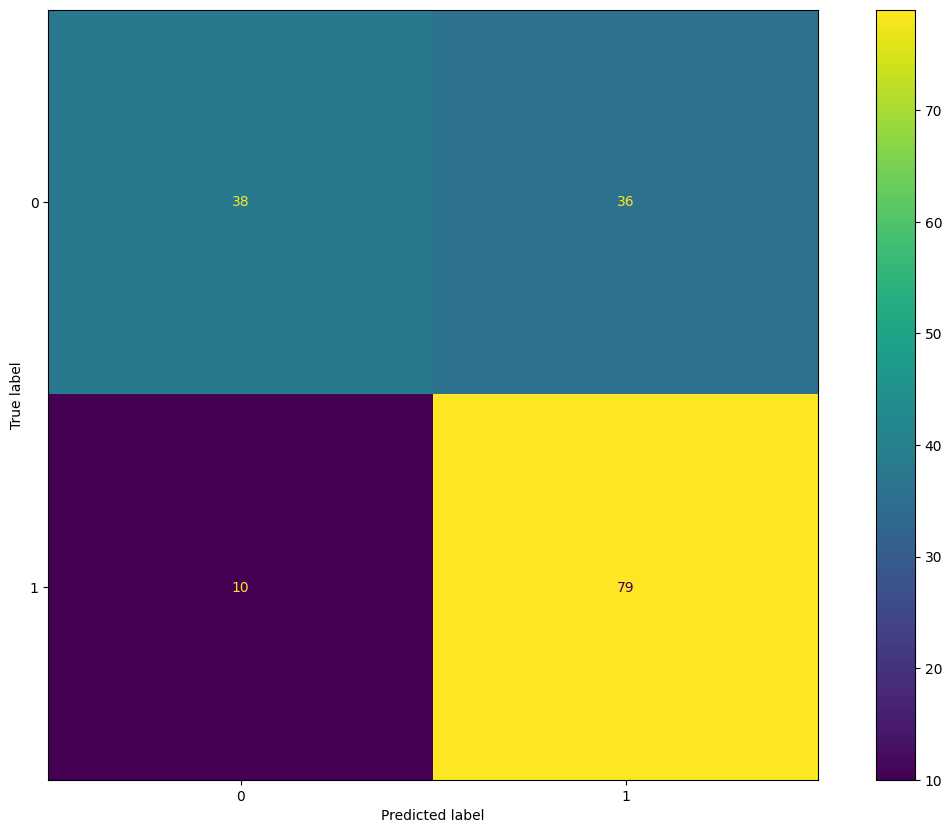

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print(classification_report(y_test, y_pred))

print("f1_score_macro : ",f1_score(y_test, y_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_test, y_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.51      0.62        74
           1       0.69      0.89      0.77        89

    accuracy                           0.72       163
   macro avg       0.74      0.70      0.70       163
weighted avg       0.73      0.72      0.71       163



# Error Analysis

In [ ]:
test_df = kaggle_df.loc[X_test_text.index]

In [ ]:
test_df['correct'] = y_pred == y_test

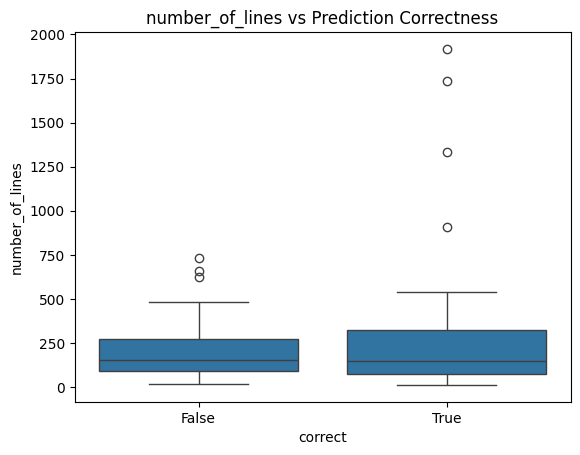

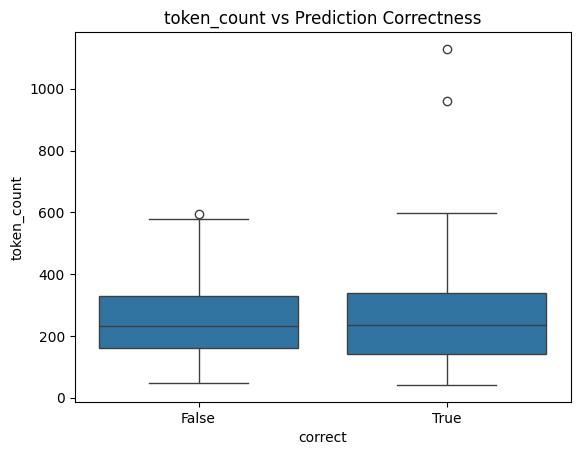

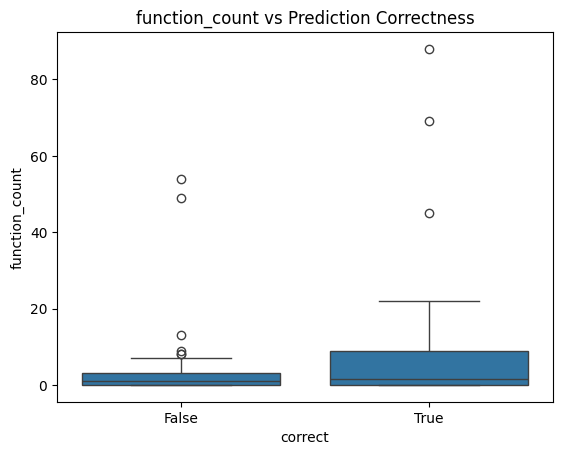

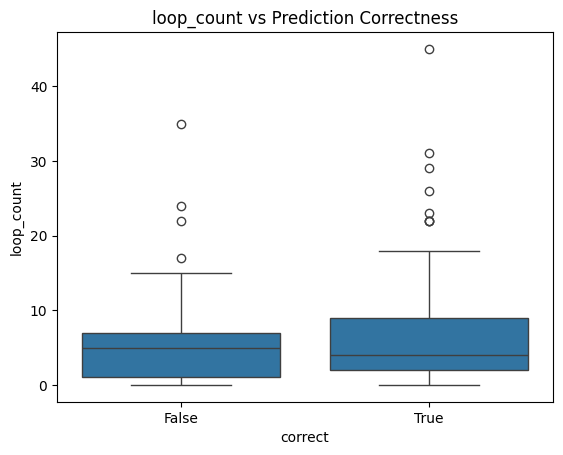

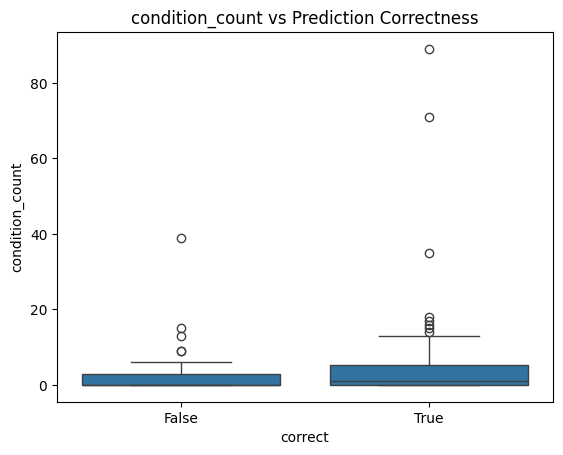

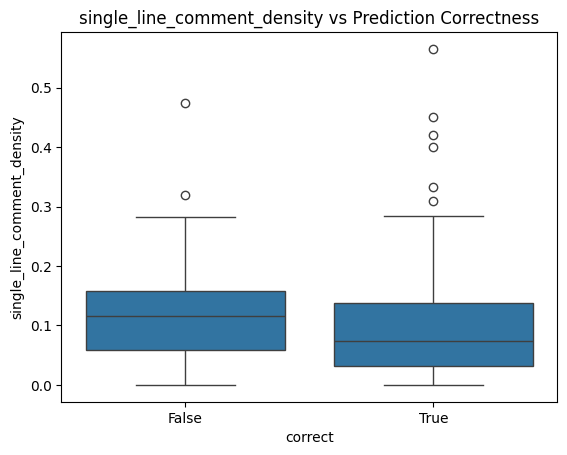

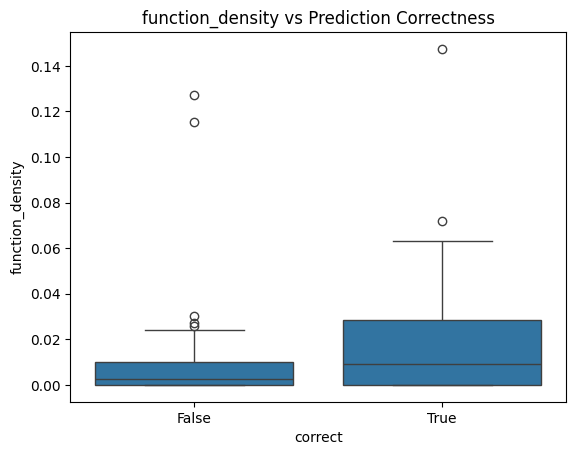

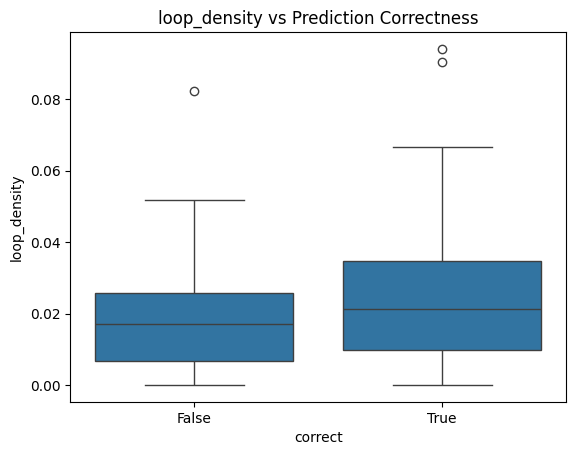

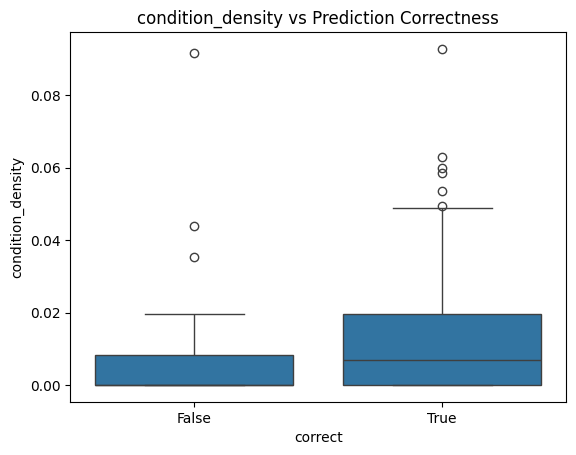

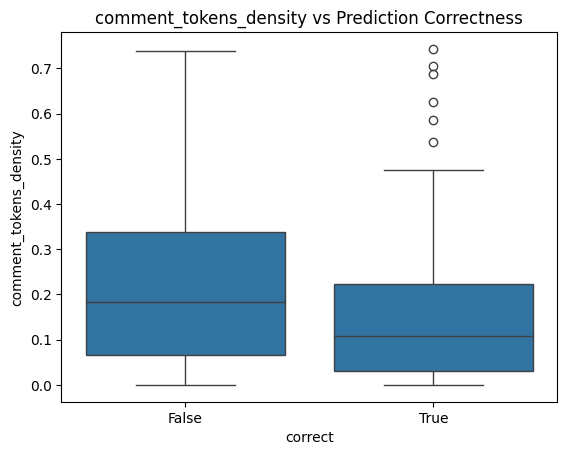

In [ ]:
import seaborn as sns

features_to_plot = [
    'number_of_lines', 'token_count', 'function_count',
    'loop_count', 'condition_count',
    'single_line_comment_density',
    'function_density', 'loop_density', 'condition_density',
    'comment_tokens_density'
]

for col in features_to_plot:
    sns.boxplot(x='correct', y=col, data=test_df)
    plt.title(f'{col} vs Prediction Correctness')
    plt.show()

In [ ]:
test_df.groupby('correct')[features_to_plot].mean().T.sort_values(by=False, ascending=False)

correct,False,True
token_count,257.490196,260.026786
number_of_lines,197.921569,239.071429
loop_count,5.882353,6.883929
function_count,3.705882,6.303571
condition_count,2.686275,4.830357
comment_tokens_density,0.221168,0.155592
single_line_comment_density,0.126403,0.101103
loop_density,0.018979,0.024729
function_density,0.010498,0.016900
condition_density,0.007267,0.013384


/tmp/ipython-input-50-3175236219.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = test_df.groupby(['token_bin', 'loop_bin'])['correct'].mean().unstack().T


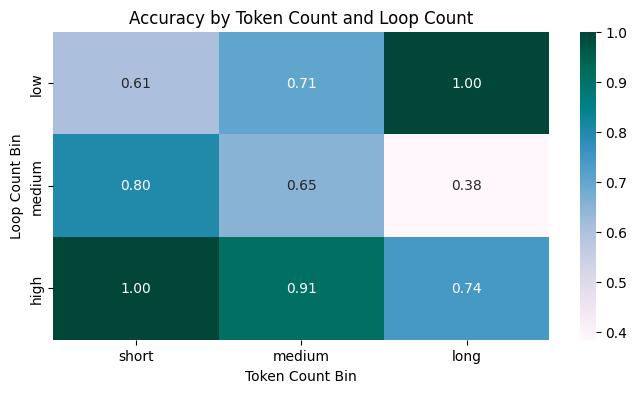

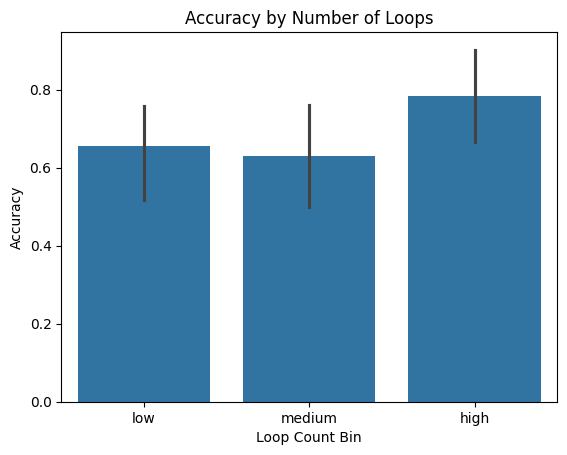

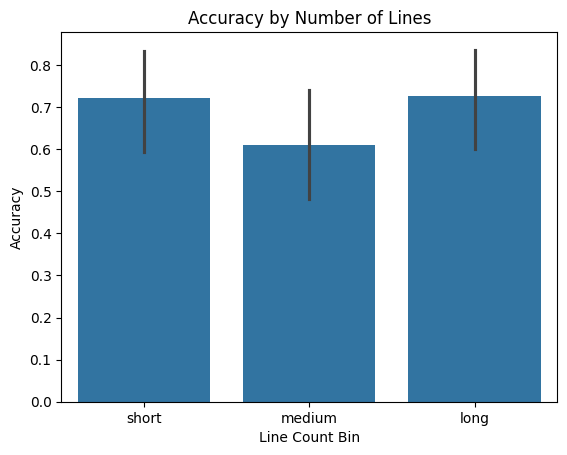

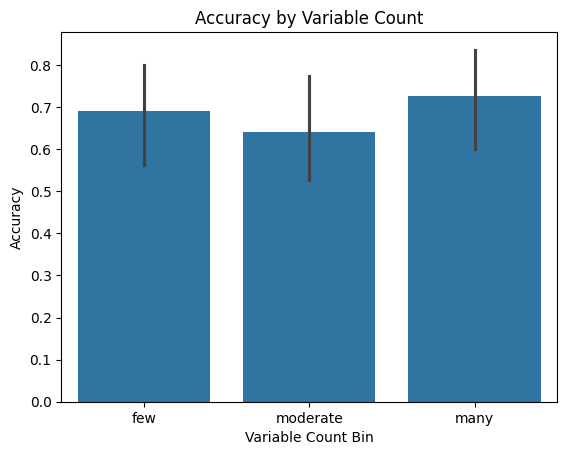

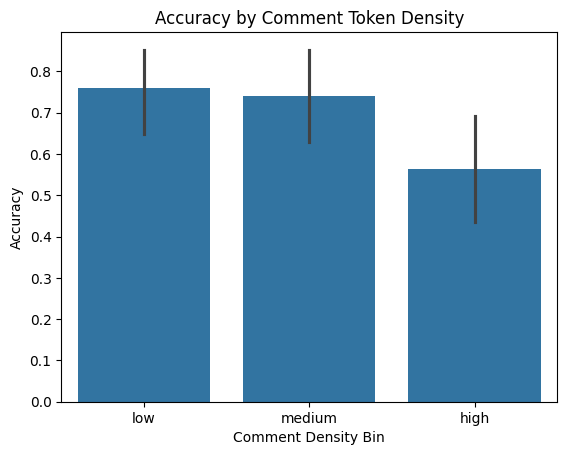

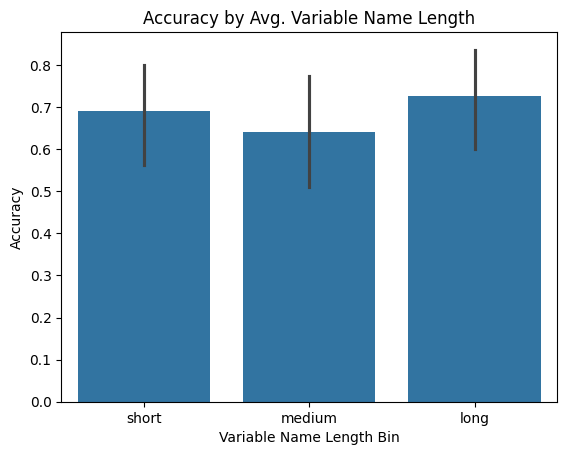

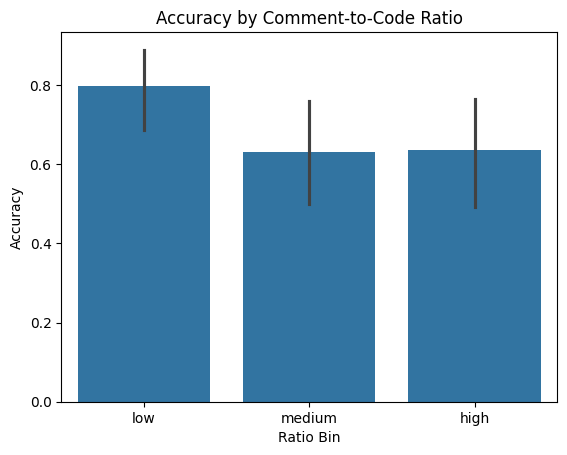

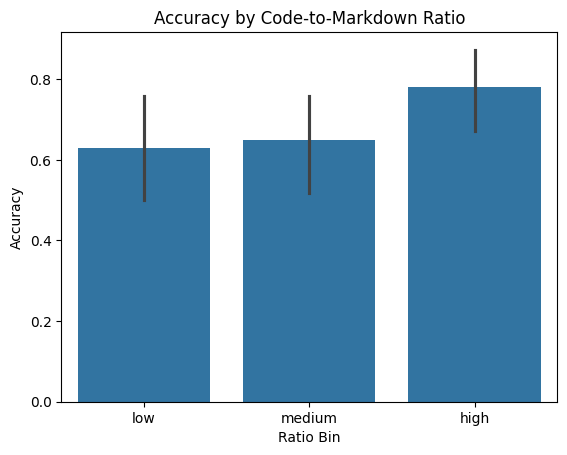

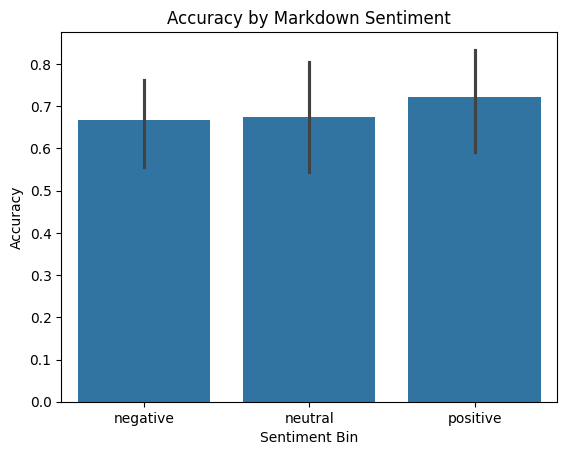

In [ ]:
# 2. Bin continuous variables
test_df['token_bin'] = pd.qcut(test_df['token_count'], 3, labels=["short", "medium", "long"])
test_df['line_bin'] = pd.qcut(test_df['number_of_lines'], 3, labels=["short", "medium", "long"])
test_df['var_bin'] = pd.qcut(test_df['variables_count'], 3, labels=["few", "moderate", "many"])
test_df['loop_bin'] = pd.qcut(test_df['loop_count'], 3, labels=["low", "medium", "high"])
test_df['comment_bin'] = pd.qcut(test_df['comment_tokens_density'], 3, labels=["low", "medium", "high"])
test_df['avg_var_len_bin'] = pd.qcut(test_df['avg_var_name_length'], 3, labels=["short", "medium", "long"])
test_df['comment_code_ratio_bin'] = pd.qcut(test_df['comment_to_code_ratio'], 3, labels=["low", "medium", "high"])
test_df['code_markdown_ratio_bin'] = pd.qcut(test_df['code_to_markdown_ratio'], 3, labels=["low", "medium", "high"])
test_df['markdown_sentiment_bin'] = pd.qcut(test_df['markdown_sentiment'], 3, labels=["negative", "neutral", "positive"])

# 3. Visualizations

# A. Token Count vs Loop Count
plt.figure(figsize=(8, 4))
heatmap_data = test_df.groupby(['token_bin', 'loop_bin'])['correct'].mean().unstack().T
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='PuBuGn')
plt.title("Accuracy by Token Count and Loop Count")
plt.xlabel("Token Count Bin")
plt.ylabel("Loop Count Bin")
plt.show()


plt.figure()
sns.barplot(data=test_df, x='loop_bin', y='correct')
plt.title("Accuracy by Number of Loops")
plt.xlabel("Loop Count Bin")
plt.ylabel("Accuracy")
plt.show()

# B. Accuracy by Number of Lines
plt.figure()
sns.barplot(data=test_df, x='line_bin', y='correct')
plt.title("Accuracy by Number of Lines")
plt.xlabel("Line Count Bin")
plt.ylabel("Accuracy")
plt.show()

# C. Accuracy by Variable Count
plt.figure()
sns.barplot(data=test_df, x='var_bin', y='correct')
plt.title("Accuracy by Variable Count")
plt.xlabel("Variable Count Bin")
plt.ylabel("Accuracy")
plt.show()

# F. Accuracy by Comment Token Density
plt.figure()
sns.barplot(data=test_df, x='comment_bin', y='correct')
plt.title("Accuracy by Comment Token Density")
plt.xlabel("Comment Density Bin")
plt.ylabel("Accuracy")
plt.show()

# G. Accuracy by Avg. Variable Name Length
plt.figure()
sns.barplot(data=test_df, x='avg_var_len_bin', y='correct')
plt.title("Accuracy by Avg. Variable Name Length")
plt.xlabel("Variable Name Length Bin")
plt.ylabel("Accuracy")
plt.show()

# H. Accuracy by Comment-to-Code Ratio
plt.figure()
sns.barplot(data=test_df, x='comment_code_ratio_bin', y='correct')
plt.title("Accuracy by Comment-to-Code Ratio")
plt.xlabel("Ratio Bin")
plt.ylabel("Accuracy")
plt.show()

# I. Accuracy by Code-to-Markdown Ratio
plt.figure()
sns.barplot(data=test_df, x='code_markdown_ratio_bin', y='correct')
plt.title("Accuracy by Code-to-Markdown Ratio")
plt.xlabel("Ratio Bin")
plt.ylabel("Accuracy")
plt.show()

# J. Accuracy by Markdown Sentiment
plt.figure()
sns.barplot(data=test_df, x='markdown_sentiment_bin', y='correct')
plt.title("Accuracy by Markdown Sentiment")
plt.xlabel("Sentiment Bin")
plt.ylabel("Accuracy")
plt.show()